<a href="https://colab.research.google.com/github/aswinss949/DSC-DEMO-PROJECT/blob/main/coding_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
import pickle

#loading dataset

In [ ]:
df_path = "/content/drive/MyDrive/partpdf_1782718651214_partpdf_1772777095672_partpdf_1763620554909_eurovision_1998 to 2012.xlsx"

In [ ]:
if 'df' in locals() or 'df' in globals():
    # Check for missing values

    print("Missing values per column:")
    print(df.isnull().sum())


#numberical values

In [ ]:
# Handling Numerical Missing Values

# Check if 'df' DataFrame exists, if not, load it from df_path
if 'df' not in locals() and 'df' not in globals():
    if 'df_path' in globals():
        try:
            df = pd.read_excel(globals()['df_path'])
            print("DataFrame 'df' loaded from df_path.")
        except FileNotFoundError:
            print(f"Error: The file '{globals()['df_path']}' was not found. Please ensure the path is correct and the file exists.")
            raise
        except Exception as e:
            print(f"An error occurred while loading the DataFrame: {e}")
            raise
    else:
        raise NameError("name 'df_path' is not defined. Cannot load DataFrame 'df'.")


numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

DataFrame 'df' loaded from df_path.


#categorical values

In [ ]:
# Handling Categorical Missing Values

categorical_cols = df.select_dtypes(include=[object]).columns
for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna('Unknown')

#checking missing values

In [ ]:

    # Verify that all missing values have been handled

    print("\nMissing values after mitigation:")
    print(df.isnull().sum())


Missing values after mitigation:
Unnamed: 0           0
Year                 0
Country              0
Region               0
Artist               0
Song                 0
Artist.gender        0
Group.Solo           0
Place                0
Points               0
Home.Away.Country    0
Home.Away.Region     0
Is.Final             0
Semi.Final.Number    0
Song.In.English      0
Song.Quality         0
Normalized.Points    0
energy               0
duration             0
acousticness         0
danceability         0
tempo                0
speechiness          0
key                  0
liveness             0
time_signature       0
mode                 0
loudness             0
valence              0
Happiness            0
dtype: int64


#Points / Normalized.Points
 Numerical Columns
we used median imputation to ensure that the missing value is replaced by the actual middle-standing performance score it keeps the imputation robust against outlier and maintain realistic dataset

#Artist / Song
categorical columns
 Imputing with the literal string 'Unknown' flags the missing entry explicitly. This allows us to keep the row intact to safely analyze non-missing features such as Year, Duration,audio features like Liveness and Danceability without corrupting individual participant data.

#heatmap

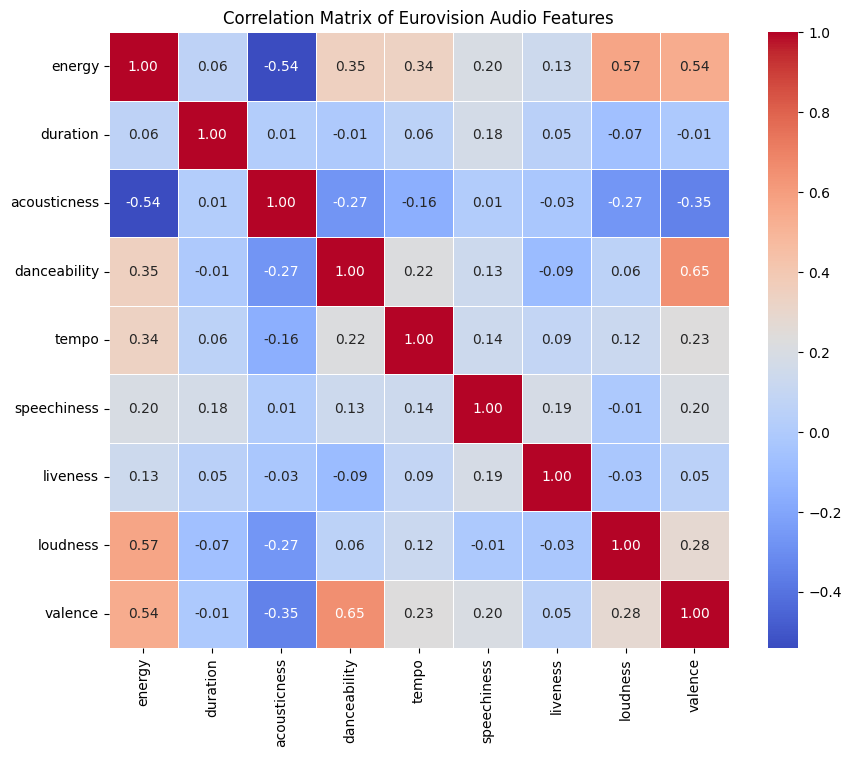

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# numeric audio features present in the dataset
audio_features = [
    'energy', 'duration', 'acousticness', 'danceability',
    'tempo', 'speechiness', 'liveness', 'loudness', 'valence'
]

# Ensure we only use columns that exist in the dataframe
audio_cols = [col for col in audio_features if col in df.columns]

#correlation matrix
corr_matrix = df[audio_cols].corr()

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Eurovision Audio Features')
plt.show()

# Feature Selection based on multicollinearity mitigation
# Retaining a representative set of 4-5 features:
reduced_audio_features = ['danceability', 'valence', 'acousticness', 'tempo', 'duration']
df_reduced = df.drop(columns=[col for col in audio_cols if col not in reduced_audio_features])

Based on the linear relationships visualized in the correlation matrix heatmap, the features were filtered to mitigate are :
danceability
valence
acousticness
tempo
duration

#discarded
energy
loudness
speechiness
liveness


#scatter plot

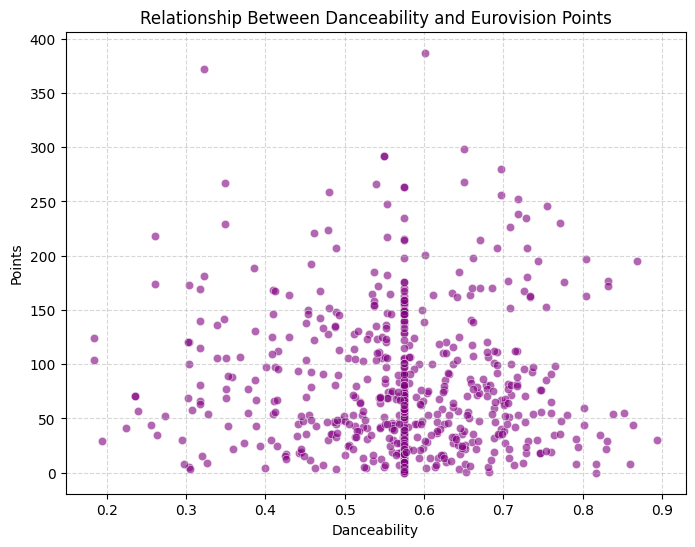

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the relationship between danceability and Points
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='danceability', y='Points', alpha=0.6, color='purple')

plt.title('Relationship Between Danceability and Eurovision Points')
plt.xlabel('Danceability')
plt.ylabel('Points')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Based on the scatter plot, there appears to be no strong or clear linear relationship between a song's danceability and the points it receives in Eurovision.The data points are heavily concentrated in a dense cluster between roughly 0.4 and 0.8 danceability

A song's danceability score is not a primary in Eurovision. High danceability is neither a requirement for scoring well points instead a song's final score is likely determined by a combination of other factors such as performance quality, staging, regional voting patterns, or vocal execution.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Prepare the data using only the selected features
# Features: 'danceability', 'valence', 'acousticness', 'tempo', 'duration'
# Target: 'Points'
X = df[reduced_audio_features]
y = df['Points']

# Split the dataset into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

# Predict on the test set and evaluate Mean Absolute Error (MAE)
y_pred = gbr_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Gradient Boosting Regressor Mean Absolute Error (MAE): {mae:.2f}")

Gradient Boosting Regressor Mean Absolute Error (MAE): 45.53


A Mean Absolute Error (MAE) of 45.53 means that, on average your Gradient Boosting model's predictions miss the actual final score of a country by about 45.53 points



In [ ]:
# Permanent save to your connected Google Drive folder
with open('/content/drive/MyDrive/gbr_model.pkl', 'wb') as file:
    pickle.dump(gbr_model, file)

print("Model permanently saved to Google Drive!")

Model permanently saved to Google Drive!


Flask Application Backend

In [ ]:
import pickle

# Save the trained Gradient Boosting model to a file
with open('gbr_model.pkl', 'wb') as file:
    pickle.dump(gbr_model, file)

print("Model successfully saved as 'gbr_model.pkl'")

Model successfully saved as 'gbr_model.pkl'


In [ ]:
from flask import Flask, request, jsonify
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained Gradient Boosting model
with open('gbr_model.pkl', 'rb') as file:
    model = pickle.load(file)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Extract JSON input from the incoming request
        data = request.get_json()

        # Parse out your 5 chosen audio features in the exact training sequence
        features = [
            float(data['danceability']),
            float(data['valence']),
            float(data['acousticness']),
            float(data['tempo']),
            float(data['duration'])
        ]

        # Structure features as a 2D array for the model ([1, 5])
        prediction_input = [features]

        # Predict the points score
        predicted_points = model.predict(prediction_input)[0]

        # Return successful response with the result rounded to two decimals
        return jsonify({
            'status': 'success',
            'predicted_points': round(float(predicted_points), 2)
        })

    except KeyError as e:
        return jsonify({
            'status': 'error',
            'message': f'Missing required audio feature field: {str(e)}'
        }), 400
    except Exception as e:
        return jsonify({
            'status': 'error',
            'message': str(e)
        }), 500

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
from google.colab import files

# This will trigger an automatic browser download for the file
files.download('gbr_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>